## **The Dataset**

### **Bank Customer Churn: Binary Classification**
In this project, we are moving from Regression to **Binary Classification**. Instead of predicting a price, we are predicting a Yes/No outcome.

We are using a dataset of 10,000 bank customers. Our goal is to predict if a customer will **Churn** (close their account and leave the bank) based on their profile.

* **Features:** Credit Score, Geography, Gender, Age, Tenure, Balance, Number of Products, Has Credit Card, Is Active Member, Estimated Salary.
* **Target:** `Exited` (1 = Customer left, 0 = Customer stayed).

## **Loading and Preprocessing**


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

# Note for Colab: Students will need to upload 'Churn_Modelling.csv' to their session
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


## **Feature Selection: Which Columns are Useless**
Before we build our neural network, we need to decide which features (columns) actually help us predict if a customer will leave.

We have three suspicious columns: `RowNumber`, `CustomerId`, and `Surname`. Logically, a customer's random ID number shouldn't affect whether they close their bank account. But in machine learning, we don't just guess—we prove it using data!

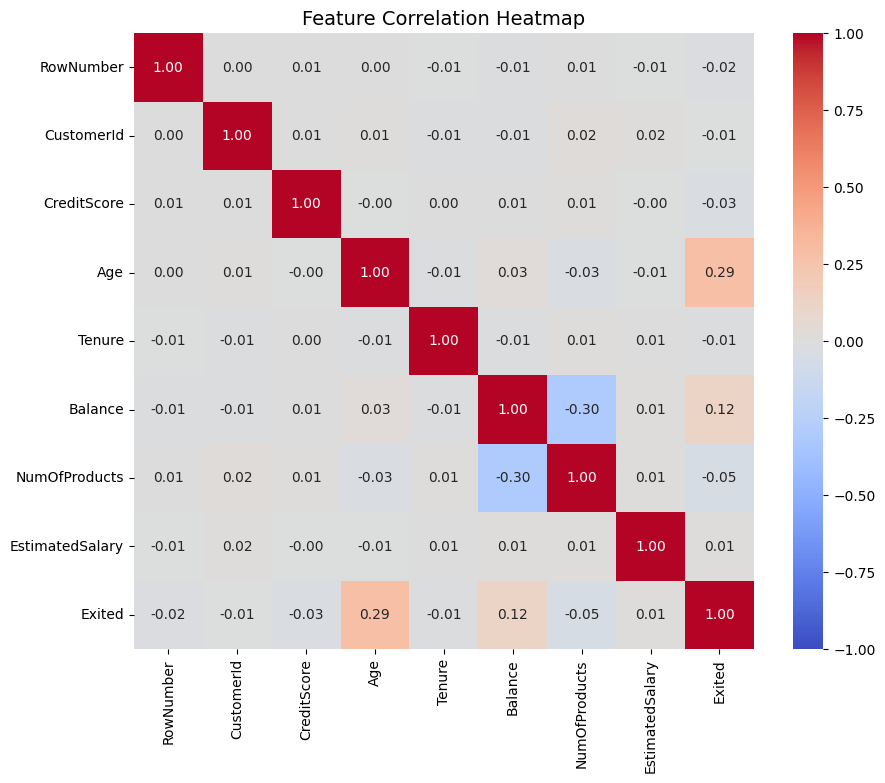

Correlation with Churn (Exited):
RowNumber: -0.0166
CustomerId: -0.0062


In [ ]:
# 1. Select only the numerical columns
numerical_cols = ['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure',
                  'Balance', 'NumOfProducts', 'EstimatedSalary', 'Exited']

# 2. Calculate the correlation matrix
correlation_matrix = df[numerical_cols].corr()

# 3. Plot the heatmap focusing on our target variable: 'Exited'
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Feature Correlation Heatmap', fontsize=14)
plt.show()

# Print a specific check for our suspicious columns
print("Correlation with Churn (Exited):")
print(f"RowNumber: {correlation_matrix['Exited']['RowNumber']:.4f}")
print(f"CustomerId: {correlation_matrix['Exited']['CustomerId']:.4f}")

In [ ]:
# 1. Drop useless columns (Name and ID don't determine if someone closes an account!)
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

# 2. One-Hot Encode categorical variables (Geography and Gender)
df_encoded = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

# 3. Separate Features and Target
X = df_encoded.drop('Exited', axis=1).values
y = df_encoded['Exited'].values

# 4. The 3-Way Split (15% Test, 15% Validation, 70% Train)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42)

# 5. Scale the features (Fit on train, transform all)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print(f"Input features count: {X_train.shape[1]}")

Input features count: 11


## **Convert to Tensors and DataLoaders**

In [ ]:
# Convert to Tensors
# Note: Even though 'y' is 0 or 1, PyTorch's binary loss function expects float32 tensors!
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=batch_size, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=batch_size, shuffle=False)

## **The Classification Model & Loss Function**

In [ ]:
class ChurnClassifierSigmoid(nn.Module):
    def __init__(self, input_features, hidden1=16, hidden2=8, out=1):
        super().__init__()
        self.layer1 = nn.Linear(input_features, hidden1)
        self.layer2 = nn.Linear(hidden1, hidden2)
        self.output_layer = nn.Linear(hidden2, out)

        self.relu = nn.Tanh()
        # 1. Define the Sigmoid activation
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))


        # 2. Apply Sigmoid directly to the final output
        x = self.sigmoid(self.output_layer(x))
        return x

model = ChurnClassifierSigmoid(input_features=X_train.shape[1])

# 3. Use the regular BCELoss (since the model now outputs probabilities)
criterion = nn.BCELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
epochs = 100
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

for epoch in range(epochs):
    # --- 1. TRAINING PHASE ---
    model.train()
    epoch_train_loss = 0
    correct_train = 0
    total_train = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()

        # The model now outputs probabilities directly because of the internal Sigmoid
        probabilities = model(batch_X)

        loss = criterion(probabilities, batch_y)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        # Calculate training accuracy for this batch
        predicted_classes = (probabilities >= 0.5).float()
        correct_train += (predicted_classes == batch_y).sum().item()
        total_train += batch_y.size(0)

    train_losses.append(epoch_train_loss / len(train_loader))
    train_accuracies.append(correct_train / total_train)

    # --- 2. VALIDATION PHASE ---
    model.eval()
    epoch_val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            probabilities = model(batch_X)
            loss = criterion(probabilities, batch_y)
            epoch_val_loss += loss.item()

            # Calculate validation accuracy for this batch
            predicted_classes = (probabilities >= 0.5).float()
            correct_val += (predicted_classes == batch_y).sum().item()
            total_val += batch_y.size(0)

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_val / total_val)

    # Print progress every 10 epochs
    if (epoch + 1) % 10 == 0:
        val_acc_percent = val_accuracies[-1] * 100
        print(f'Epoch [{epoch+1}/{epochs}] | Val Loss: {val_losses[-1]:.4f} | Val Accuracy: {val_acc_percent:.2f}%')

Epoch [10/100] | Val Loss: 0.4436 | Val Accuracy: 80.33%
Epoch [20/100] | Val Loss: 0.4323 | Val Accuracy: 80.92%
Epoch [30/100] | Val Loss: 0.4248 | Val Accuracy: 81.44%
Epoch [40/100] | Val Loss: 0.4138 | Val Accuracy: 82.09%
Epoch [50/100] | Val Loss: 0.4001 | Val Accuracy: 83.07%
Epoch [60/100] | Val Loss: 0.3849 | Val Accuracy: 84.31%
Epoch [70/100] | Val Loss: 0.3718 | Val Accuracy: 85.10%
Epoch [80/100] | Val Loss: 0.3621 | Val Accuracy: 86.34%
Epoch [90/100] | Val Loss: 0.3557 | Val Accuracy: 86.54%
Epoch [100/100] | Val Loss: 0.3520 | Val Accuracy: 86.86%


## **Plotting Loss and Accuracy**
For classification, plotting the Loss is important to check for overfitting, but plotting the Accuracy is what humans actually care about. We will plot them side-by-side using Matplotlib.

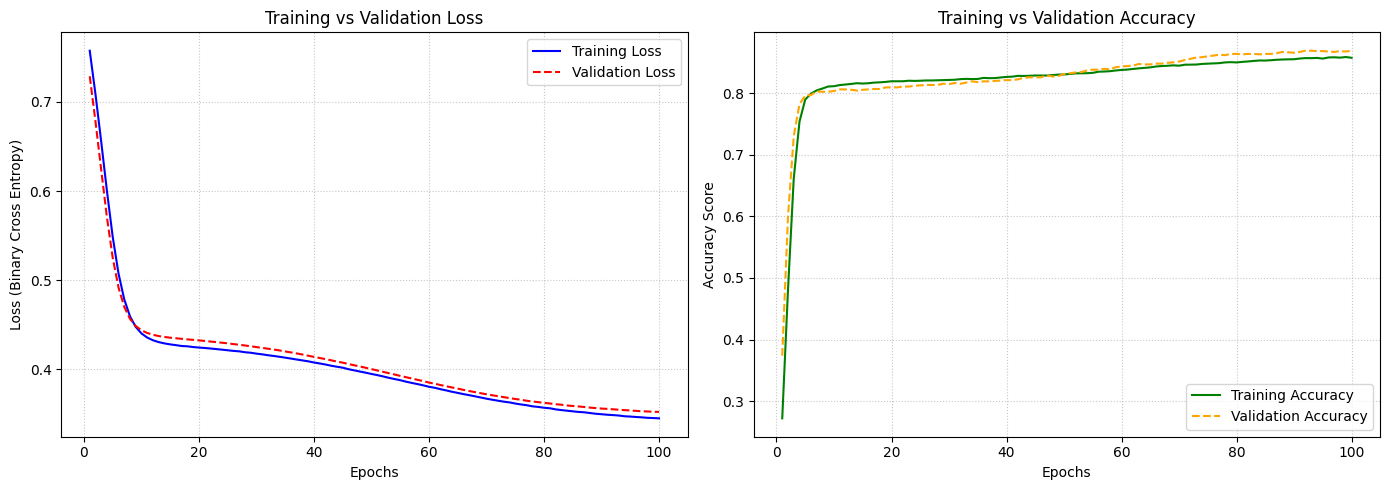

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# --- PLOT 1: Loss Curve ---
plt.subplot(1, 2, 1)
plt.plot(range(1, epochs + 1), train_losses, label='Training Loss', color='blue')
plt.plot(range(1, epochs + 1), val_losses, label='Validation Loss', color='red', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Loss (Binary Cross Entropy)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# --- PLOT 2: Accuracy Curve ---
plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), train_accuracies, label='Training Accuracy', color='green')
plt.plot(range(1, epochs + 1), val_accuracies, label='Validation Accuracy', color='orange', linestyle='--')
plt.xlabel('Epochs')
plt.ylabel('Accuracy Score')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

## **The Final Evaluation (Test Set)**
Once you and your students review the plots and confirm the model isn't overfitting (the validation lines stay relatively stable with the training lines), you unlock the test set for the final grade.

In [ ]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        # Get the direct probabilities from the model
        probabilities = model(batch_X)

        # Threshold at 0.5 to decide 1 (Churn) or 0 (Stay)
        predictions = (probabilities >= 0.5).float()

        test_correct += (predictions == batch_y).sum().item()
        test_total += batch_y.size(0)

final_accuracy = (test_correct / test_total) * 100

print("=" * 40)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("=" * 40)

# Display 5 specific customer examples
print("\nSample Customer Predictions:")
for i in range(5):
    # Convert back to standard numbers for printing
    prob = probabilities[i].item() * 100
    pred = int(predictions[i].item())
    actual = int(batch_y[i].item())

    # Format the text to make it easy to read
    status = "LEFT" if pred == 1 else "STAYED"
    print(f"Customer {i+1}: Model predicted {status} (Certainty: {prob:.1f}%) | Actual: {actual}")

FINAL TEST ACCURACY: 86.47%

Sample Customer Predictions:
Customer 1: Model predicted STAYED (Certainty: 20.4%) | Actual: 0
Customer 2: Model predicted LEFT (Certainty: 52.3%) | Actual: 1
Customer 3: Model predicted STAYED (Certainty: 22.1%) | Actual: 0
Customer 4: Model predicted STAYED (Certainty: 5.6%) | Actual: 0
Customer 5: Model predicted STAYED (Certainty: 17.4%) | Actual: 0


<br><br>

## **The Classification Model & Loss Function**

For Binary Classification, we use Binary Cross Entropy (BCE) loss. The safest and most professional version in PyTorch is nn.BCEWithLogitsLoss(). Because of how this specific loss function does its math, we do not put a Sigmoid activation on our final output layer. The loss function handles it automatically under the hood to prevent math errors!

In [ ]:
class ChurnClassifier(nn.Module):
    def __init__(self, input_features, hidden1=16, hidden2=8, out=1):
        super().__init__()
        self.layer1 = nn.Linear(input_features, hidden1)
        self.layer2 = nn.Linear(hidden1, hidden2)
        self.output_layer = nn.Linear(hidden2, out) # Still 1 output! (Will it be 0 or 1?)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2) # Keeping dropout to prevent overfitting

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        # Raw output (called "Logits"). No Sigmoid here!
        x = self.output_layer(x)
        return x

model = ChurnClassifier(input_features=X_train.shape[1])

# The Loss Function for Binary Classification
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


## **The Training Loop (Now Tracking Accuracy)**
With classification, looking at just the "Loss" number isn't very intuitive for humans. We want to know the Accuracy (what percentage did it guess correctly?). We can calculate that inside our loop.

In [ ]:
epochs = 100
train_losses, val_losses = [], []
val_accuracies = []

for epoch in range(epochs):
    # --- TRAINING ---
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))

    # --- VALIDATION ---
    model.eval()
    epoch_val_loss = 0
    correct_guesses = 0
    total_guesses = 0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            raw_predictions = model(batch_X)
            loss = criterion(raw_predictions, batch_y)
            epoch_val_loss += loss.item()

            # Convert raw outputs into probabilities using Sigmoid
            probabilities = torch.sigmoid(raw_predictions)

            # Convert probabilities into firm 0s or 1s (threshold at 0.5)
            predicted_classes = (probabilities >= 0.5).float()

            # Count how many match the true labels
            correct_guesses += (predicted_classes == batch_y).sum().item()
            total_guesses += batch_y.size(0)

    val_losses.append(epoch_val_loss / len(val_loader))
    val_accuracies.append(correct_guesses / total_guesses)

    if (epoch + 1) % 10 == 0:
        acc_percent = val_accuracies[-1] * 100
        print(f'Epoch [{epoch+1}/{epochs}] | Val Loss: {val_losses[-1]:.4f} | Val Accuracy: {acc_percent:.2f}%')


Epoch [10/100] | Val Loss: 0.3481 | Val Accuracy: 86.01%
Epoch [20/100] | Val Loss: 0.3423 | Val Accuracy: 86.21%
Epoch [30/100] | Val Loss: 0.3400 | Val Accuracy: 86.86%
Epoch [40/100] | Val Loss: 0.3404 | Val Accuracy: 86.27%
Epoch [50/100] | Val Loss: 0.3411 | Val Accuracy: 86.01%
Epoch [60/100] | Val Loss: 0.3444 | Val Accuracy: 85.95%
Epoch [70/100] | Val Loss: 0.3450 | Val Accuracy: 86.01%
Epoch [80/100] | Val Loss: 0.3473 | Val Accuracy: 86.47%
Epoch [90/100] | Val Loss: 0.3467 | Val Accuracy: 86.21%
Epoch [100/100] | Val Loss: 0.3489 | Val Accuracy: 86.27%


## **Evaluation and The Sigmoid Explanation**

In [ ]:
model.eval()
test_correct = 0
test_total = 0

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        raw_outputs = model(batch_X)

        # Step 1: Squish raw numbers into a probability between 0 and 1
        probabilities = torch.sigmoid(raw_outputs)

        # Step 2: If probability is >= 50%, predict 1 (Churn). Else, predict 0 (Stay).
        predictions = (probabilities >= 0.5).float()

        test_correct += (predictions == batch_y).sum().item()
        test_total += batch_y.size(0)

final_accuracy = (test_correct / test_total) * 100
print("-" * 30)
print(f"FINAL TEST ACCURACY: {final_accuracy:.2f}%")
print("-" * 30)

# Show a few specific examples to the students
print("Let's look at 5 specific customers:")
for i in range(5):
    prob = probabilities[i].item() * 100
    pred = int(predictions[i].item())
    actual = int(batch_y[i].item())

    print(f"Model certainty of leaving: {prob:.1f}% --> Guessed: {pred} | Actual: {actual}")

------------------------------
FINAL TEST ACCURACY: 86.47%
------------------------------
Let's look at 5 specific customers:
Model certainty of leaving: 27.8% --> Guessed: 0 | Actual: 0
Model certainty of leaving: 61.6% --> Guessed: 1 | Actual: 1
Model certainty of leaving: 27.1% --> Guessed: 0 | Actual: 0
Model certainty of leaving: 5.4% --> Guessed: 0 | Actual: 0
Model certainty of leaving: 15.7% --> Guessed: 0 | Actual: 0
